In [1]:
import cv2
from skimage.util import random_noise
import numpy as np
from matplotlib import pyplot as plt

像素(100,100) BGR：242, 220, 255


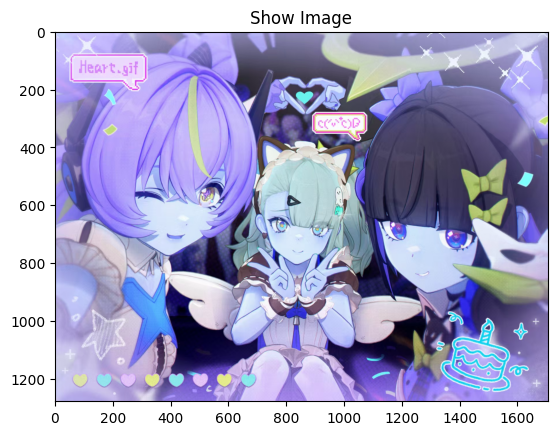

In [2]:
#读取并显示原始图像
img = cv2.imread('p1.jpg')
(b, g, r) = img[100, 100]
print(f"像素(100,100) BGR：{b}, {g}, {r}")
plt.imshow(img)
plt.title('Show Image')
plt.savefig('output_images/original_bgr.jpg', dpi=300)
plt.show()

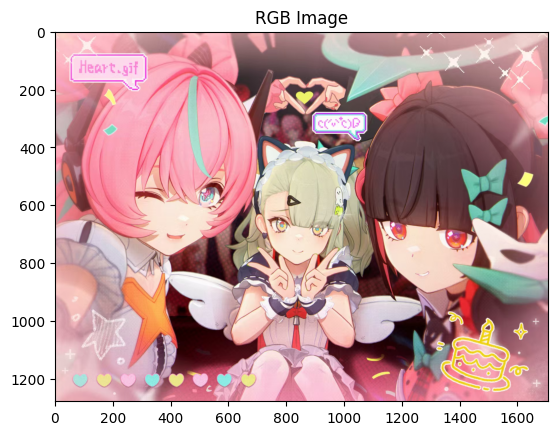

In [3]:
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img)
plt.title('RGB Image')
plt.savefig('output_images/rgb_image.jpg', dpi=300)
plt.show()

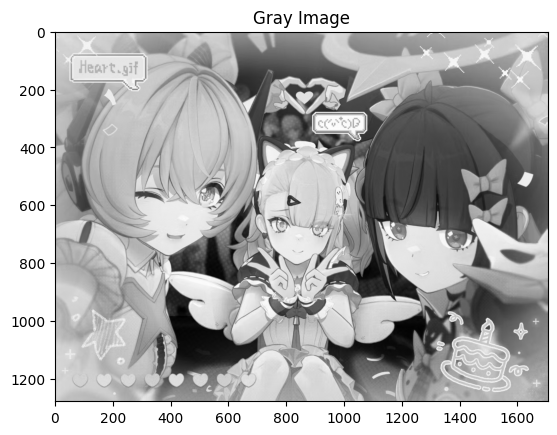

In [4]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')
plt.title('Gray Image')
plt.savefig('output_images/gray_image.jpg', dpi=300)
plt.show()

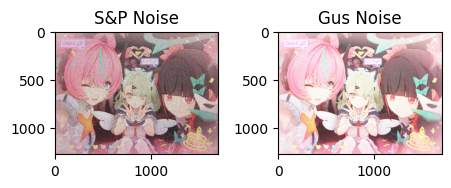

In [5]:
# 椒盐噪声 amount=0.4 40%像素被噪声污染
sp_noise_img = random_noise(rgb_img, mode='s&p', amount=0.3)
# 高斯噪声 mean均值，var方差
gus_noise_img = random_noise(rgb_img, mode='gaussian', mean=0.2, var=0.03)

plt.subplot(1, 3, 2)
plt.imshow(sp_noise_img)
plt.title('S&P Noise')

plt.subplot(1, 3, 3)
plt.imshow(gus_noise_img)
plt.title('Gus Noise')

plt.tight_layout()
plt.savefig('output_images/noise_comparison.jpg', dpi=300)
plt.show()

In [6]:
# 均值滤波
mean_sp = cv2.blur(sp_noise_img, (5, 5))
mean_gus = cv2.blur(gus_noise_img, (5, 5))

In [7]:
#中值滤波
mid_sp = cv2.medianBlur((sp_noise_img * 255).astype(np.uint8), 5)
mid_gus = cv2.medianBlur((gus_noise_img * 255).astype(np.uint8), 5)

In [8]:
#高斯滤波
gauss_sp = cv2.GaussianBlur((sp_noise_img * 255).astype(np.uint8), (5, 5), 0)
gauss_gus = cv2.GaussianBlur((gus_noise_img * 255).astype(np.uint8), (5, 5), 0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9895196601282807e-15..1.0000000000000027].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10935410987929593..1.0000000000000058].


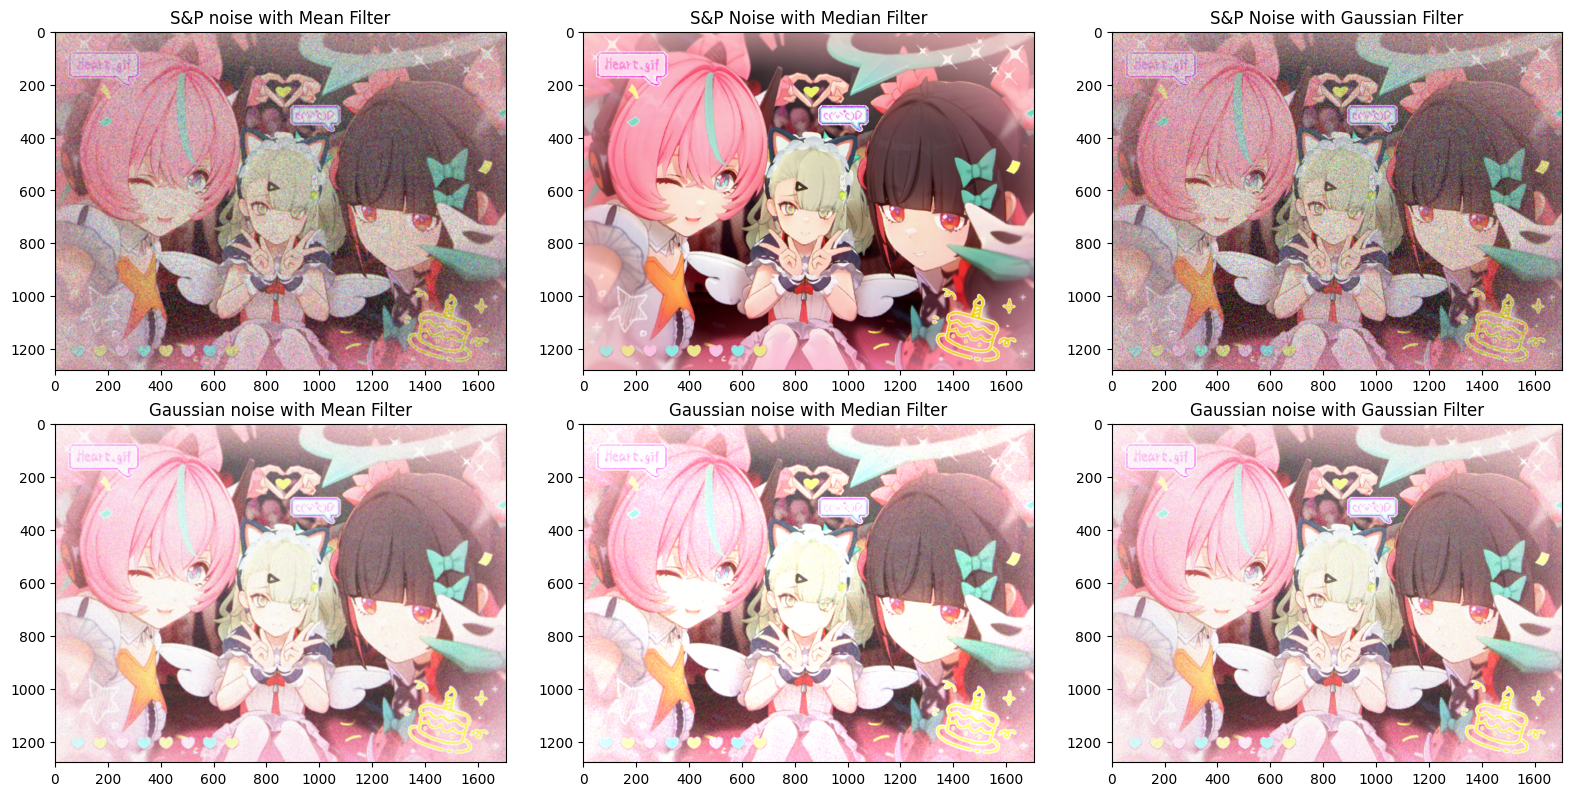

In [11]:
plt.figure(figsize=(16, 8), dpi=100) # 设置画布大小，放大图片

# 第一行：椒盐噪声的三种滤波
plt.subplot(2, 3, 1)
plt.imshow(mean_sp)
plt.title("S&P noise with Mean Filter", fontsize=12)

plt.subplot(2, 3, 2)
plt.imshow(mid_sp)
plt.title("S&P Noise with Median Filter", fontsize=12)

plt.subplot(2, 3, 3)
plt.imshow(gauss_sp)
plt.title("S&P Noise with Gaussian Filter", fontsize=12)
# 第二行：高斯噪声的三种滤波
plt.subplot(2, 3, 4)
plt.imshow(mean_gus)
plt.title("Gaussian noise with Mean Filter", fontsize=12)

plt.subplot(2, 3, 5)
plt.imshow(mid_gus)
plt.title("Gaussian noise with Median Filter", fontsize=12)

plt.subplot(2, 3, 6)
plt.imshow(gauss_gus)
plt.title("Gaussian noise with Gaussian Filter", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
def manual_median_filter_color(image, kernel_size=5):
    """
    手动实现彩色图像的中值滤波
    :param image: 输入彩色图像,numpy数组,shape=(H, W, 3) uint8
    :param kernel_size: 滤波窗口大小
    :return: 中值滤波后的彩色图像
    """
    pad = kernel_size // 2
    filtered_img = np.zeros_like(image)
    # 逐个通道处理
    for c in range(3):
        channel = image[:, :, c]
        # 边缘填充
        padded_channel = np.pad(channel, pad_width=pad, mode='edge')
        h, w = channel.shape
        for i in range(h):
            for j in range(w):
                region = padded_channel[i:i + kernel_size, j:j + kernel_size]
                filtered_img[i, j, c] = np.median(region)
    return filtered_img

# 椒盐噪声图转uint8输入手动滤波
manual_mid = manual_median_filter_color((sp_noise_img * 255).astype(np.uint8), kernel_size=5)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sp_noise_img)
plt.title("s&p noise img")

plt.subplot(1, 2, 2)
plt.imshow(manual_mid)
plt.title("manual median filter")